In [1]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import IsolationForest
from sklearn.neighbors import LocalOutlierFactor
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt


In [2]:
# Load dataset
data = pd.read_csv("creditcard.csv")

# Quick overview
print(data.head())
print(data.info())
print(data['Class'].value_counts())

# Scale Amount and Time
scaler = StandardScaler()
data['Amount'] = scaler.fit_transform(data[['Amount']])
data['Time'] = scaler.fit_transform(data[['Time']])


   Time        V1        V2        V3        V4        V5        V6        V7  \
0   0.0 -1.359807 -0.072781  2.536347  1.378155 -0.338321  0.462388  0.239599   
1   0.0  1.191857  0.266151  0.166480  0.448154  0.060018 -0.082361 -0.078803   
2   1.0 -1.358354 -1.340163  1.773209  0.379780 -0.503198  1.800499  0.791461   
3   1.0 -0.966272 -0.185226  1.792993 -0.863291 -0.010309  1.247203  0.237609   
4   2.0 -1.158233  0.877737  1.548718  0.403034 -0.407193  0.095921  0.592941   

         V8        V9  ...       V21       V22       V23       V24       V25  \
0  0.098698  0.363787  ... -0.018307  0.277838 -0.110474  0.066928  0.128539   
1  0.085102 -0.255425  ... -0.225775 -0.638672  0.101288 -0.339846  0.167170   
2  0.247676 -1.514654  ...  0.247998  0.771679  0.909412 -0.689281 -0.327642   
3  0.377436 -1.387024  ... -0.108300  0.005274 -0.190321 -1.175575  0.647376   
4 -0.270533  0.817739  ... -0.009431  0.798278 -0.137458  0.141267 -0.206010   

        V26       V27       V28 

In [3]:
X = data.drop('Class', axis=1)
y = data['Class']  # 1 = fraud, 0 = normal


In [4]:
# Fit Isolation Forest
iso = IsolationForest(
    n_estimators=100,  # number of trees
    max_samples='auto',
    contamination=float(y.sum()) / len(y),  # proportion of fraud cases
    random_state=42
)

iso.fit(X)

# Predict: -1 = anomaly (fraud), 1 = normal
y_pred_iso = iso.predict(X)
y_pred_iso = np.where(y_pred_iso == -1, 1, 0)  # convert to match Class column


In [5]:
lof = LocalOutlierFactor(
    n_neighbors=20,
    contamination=float(y.sum()) / len(y)
)

y_pred_lof = lof.fit_predict(X)
y_pred_lof = np.where(y_pred_lof == -1, 1, 0)  # convert to match Class column


In [6]:
# Isolation Forest Performance
print("=== Isolation Forest ===")
print(confusion_matrix(y, y_pred_iso))
print(classification_report(y, y_pred_iso))

# LOF Performance
print("=== Local Outlier Factor ===")
print(confusion_matrix(y, y_pred_lof))
print(classification_report(y, y_pred_lof))


=== Isolation Forest ===
[[283949    366]
 [   366    126]]
              precision    recall  f1-score   support

           0       1.00      1.00      1.00    284315
           1       0.26      0.26      0.26       492

    accuracy                           1.00    284807
   macro avg       0.63      0.63      0.63    284807
weighted avg       1.00      1.00      1.00    284807

=== Local Outlier Factor ===
[[283823    492]
 [   492      0]]
              precision    recall  f1-score   support

           0       1.00      1.00      1.00    284315
           1       0.00      0.00      0.00       492

    accuracy                           1.00    284807
   macro avg       0.50      0.50      0.50    284807
weighted avg       1.00      1.00      1.00    284807



In [7]:
from sklearn.svm import OneClassSVM

svm = OneClassSVM(kernel='rbf', gamma=0.001, nu=float(y.sum())/len(y))
svm.fit(X)
y_pred_svm = svm.predict(X)
y_pred_svm = np.where(y_pred_svm == -1, 1, 0)

print("=== One-Class SVM ===")
print(confusion_matrix(y, y_pred_svm))
print(classification_report(y, y_pred_svm))


=== One-Class SVM ===
[[283924    391]
 [   387    105]]
              precision    recall  f1-score   support

           0       1.00      1.00      1.00    284315
           1       0.21      0.21      0.21       492

    accuracy                           1.00    284807
   macro avg       0.61      0.61      0.61    284807
weighted avg       1.00      1.00      1.00    284807



Class
0    284315
1       492
Name: count, dtype: int64


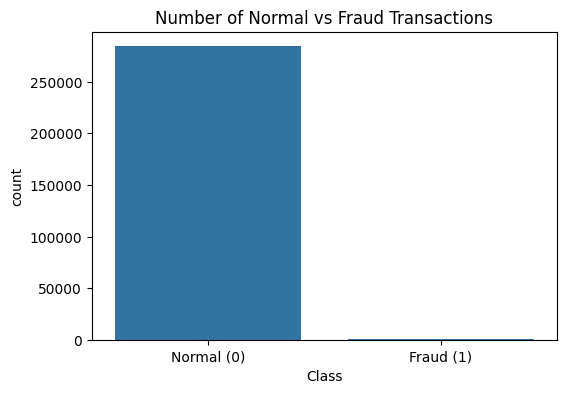

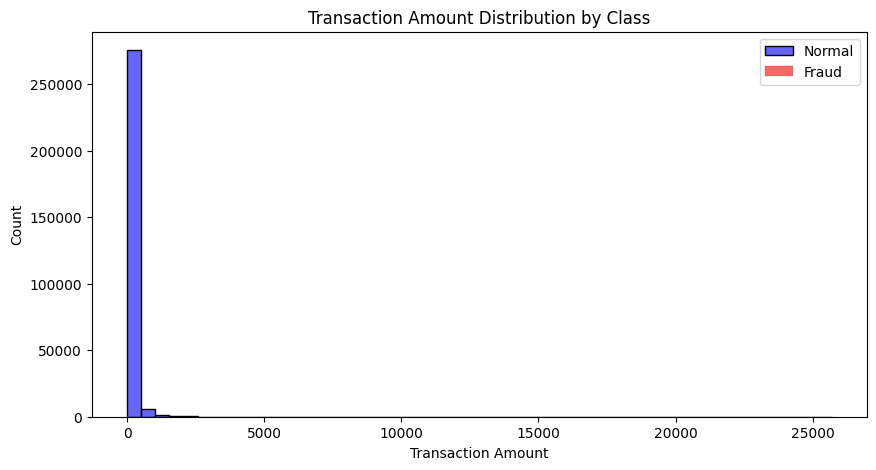

=== Isolation Forest ===
Confusion Matrix:
[[283949    366]
 [   366    126]]

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00    284315
           1       0.26      0.26      0.26       492

    accuracy                           1.00    284807
   macro avg       0.63      0.63      0.63    284807
weighted avg       1.00      1.00      1.00    284807

=== Local Outlier Factor ===
Confusion Matrix:
[[283823    492]
 [   492      0]]

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00    284315
           1       0.00      0.00      0.00       492

    accuracy                           1.00    284807
   macro avg       0.50      0.50      0.50    284807
weighted avg       1.00      1.00      1.00    284807



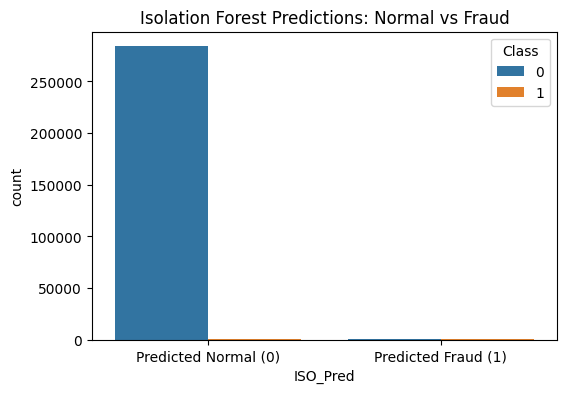

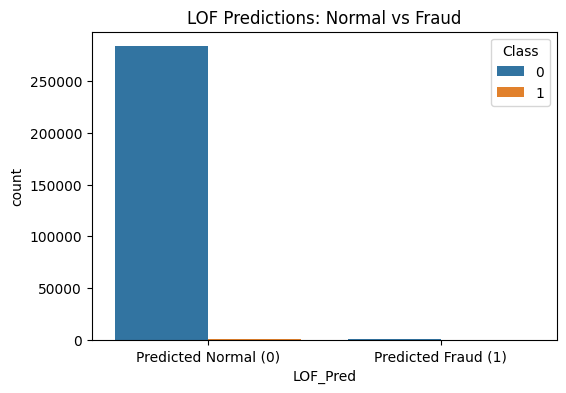

In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import IsolationForest
from sklearn.neighbors import LocalOutlierFactor
from sklearn.metrics import classification_report, confusion_matrix

# --------------------------
# 1. Load Dataset
# --------------------------
data = pd.read_csv("creditcard.csv")
print(data['Class'].value_counts())

# --------------------------
# 2. Exploratory Data Analysis (EDA)
# --------------------------

# Plot number of normal vs fraud transactions
plt.figure(figsize=(6,4))
sns.countplot(x='Class', data=data)
plt.title("Number of Normal vs Fraud Transactions")
plt.xticks([0,1], ['Normal (0)', 'Fraud (1)'])
plt.show()

# Plot distribution of transaction amounts by class
plt.figure(figsize=(10,5))
sns.histplot(data=data[data['Class']==0]['Amount'], color='blue', label='Normal', bins=50, alpha=0.6)
sns.histplot(data=data[data['Class']==1]['Amount'], color='red', label='Fraud', bins=50, alpha=0.6)
plt.title("Transaction Amount Distribution by Class")
plt.xlabel("Transaction Amount")
plt.ylabel("Count")
plt.legend()
plt.show()

# --------------------------
# 3. Preprocess Features
# --------------------------
X = data.drop('Class', axis=1)
y = data['Class']

scaler = StandardScaler()
X['Amount'] = scaler.fit_transform(X[['Amount']])
X['Time'] = scaler.fit_transform(X[['Time']])

# --------------------------
# 4. Isolation Forest
# --------------------------
iso = IsolationForest(
    n_estimators=100,
    max_samples='auto',
    contamination=float(y.sum()) / len(y),
    random_state=42
)
iso.fit(X)
y_pred_iso = iso.predict(X)
y_pred_iso = np.where(y_pred_iso == -1, 1, 0)  # convert to match Class column

# --------------------------
# 5. Local Outlier Factor (LOF)
# --------------------------
lof = LocalOutlierFactor(
    n_neighbors=20,
    contamination=float(y.sum()) / len(y)
)
y_pred_lof = lof.fit_predict(X)
y_pred_lof = np.where(y_pred_lof == -1, 1, 0)  # convert to match Class column

# --------------------------
# 6. Evaluate Models
# --------------------------
def evaluate_model(y_true, y_pred, model_name):
    print(f"=== {model_name} ===")
    print("Confusion Matrix:")
    print(confusion_matrix(y_true, y_pred))
    print("\nClassification Report:")
    print(classification_report(y_true, y_pred))

evaluate_model(y, y_pred_iso, "Isolation Forest")
evaluate_model(y, y_pred_lof, "Local Outlier Factor")

# --------------------------
# 7. Visualize Predictions
# --------------------------

# Add predictions to dataframe for plotting
data['ISO_Pred'] = y_pred_iso
data['LOF_Pred'] = y_pred_lof

# Compare true vs predicted for Isolation Forest
plt.figure(figsize=(6,4))
sns.countplot(x='ISO_Pred', hue='Class', data=data)
plt.title("Isolation Forest Predictions: Normal vs Fraud")
plt.xticks([0,1], ['Predicted Normal (0)', 'Predicted Fraud (1)'])
plt.show()

# Compare true vs predicted for LOF
plt.figure(figsize=(6,4))
sns.countplot(x='LOF_Pred', hue='Class', data=data)
plt.title("LOF Predictions: Normal vs Fraud")
plt.xticks([0,1], ['Predicted Normal (0)', 'Predicted Fraud (1)'])
plt.show()
